In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('Role_based_matching.xlsx')

In [4]:
df.head()

,Candidate,Skills,Best Role,Best Score,Fit Category
0,DASARI HARSHINI,"['python', 'c']",Data Analytics Intern,10,Low Fit
1,AADITYA MEHTA,"['html', 'css', 'javascript', 'mysql', 'sql', ...",Web Developement Intern,80,Strong Fit
2,AASTHA BAJPAI,"['python', 'html', 'css', 'javascript', 'mysql...",Web Developement Intern,100,Strong Fit
3,AASTHA VINOD,"['excel', 'word']",HR/Operations Intern,20,Low Fit
4,AAYUSH KUMAR CHAURASIA,"['python', 'html', 'css', 'javascript', 'sql',...",Web Developement Intern,60,Moderate Fit


# EDA

In [5]:
df.shape

(184, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Candidate     184 non-null    object
 1   Skills        184 non-null    object
 2   Best Role     184 non-null    object
 3   Best Score    184 non-null    int64 
 4   Fit Category  184 non-null    object
dtypes: int64(1), object(4)
memory usage: 7.3+ KB


In [7]:
df.describe()

,Best Score
count,184.000000
mean,54.728261
std,26.196652
min,10.000000
25%,30.000000
50%,60.000000
75%,80.000000
max,100.000000


In [8]:
df.isnull().sum()

Candidate       0
Skills          0
Best Role       0
Best Score      0
Fit Category    0
dtype: int64

In [9]:
df.columns

Index(['Candidate', 'Skills', 'Best Role', 'Best Score', 'Fit Category'], dtype='object')

<Axes: xlabel='Best Score', ylabel='count'>

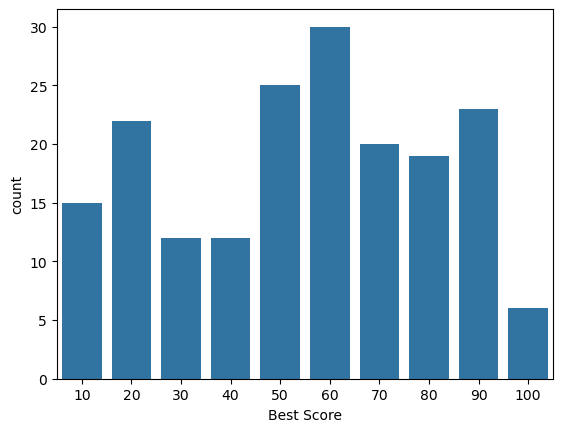

In [10]:
sns.countplot(x=df['Best Score'])

<Axes: xlabel='count', ylabel='Best Role'>

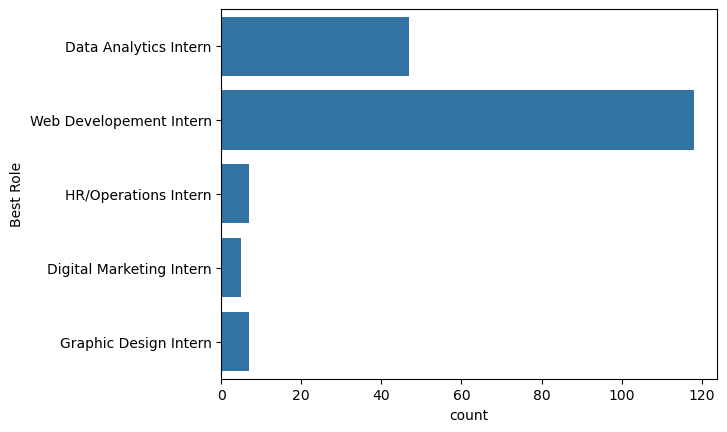

In [11]:
sns.countplot(df['Best Role'])

# Data Cleaning and Processing

In [12]:
df.head()

,Candidate,Skills,Best Role,Best Score,Fit Category
0,DASARI HARSHINI,"['python', 'c']",Data Analytics Intern,10,Low Fit
1,AADITYA MEHTA,"['html', 'css', 'javascript', 'mysql', 'sql', ...",Web Developement Intern,80,Strong Fit
2,AASTHA BAJPAI,"['python', 'html', 'css', 'javascript', 'mysql...",Web Developement Intern,100,Strong Fit
3,AASTHA VINOD,"['excel', 'word']",HR/Operations Intern,20,Low Fit
4,AAYUSH KUMAR CHAURASIA,"['python', 'html', 'css', 'javascript', 'sql',...",Web Developement Intern,60,Moderate Fit


In [13]:
df.shape

(184, 5)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(184, 5)

In [16]:
df.isnull().sum()

Candidate       0
Skills          0
Best Role       0
Best Score      0
Fit Category    0
dtype: int64

In [17]:
df.dtypes

Candidate       object
Skills          object
Best Role       object
Best Score       int64
Fit Category    object
dtype: object

In [18]:
df['Best Role'].value_counts()

Best Role
Web Developement Intern     118
Data Analytics Intern        47
HR/Operations Intern          7
Graphic Design Intern         7
Digital Marketing Intern      5
Name: count, dtype: int64

In [19]:
print(type(df['Skills'][0]))

<class 'str'>


In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

df['Skills'] = df['Skills'].str.replace(",", " ")
df['Skills'] = df['Skills'].str.lower()

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [21]:
X = vectorizer.fit_transform(df['Skills'])
y = df['Best Role']

# Feature Engineering and Extraction

In [87]:
X = df_final.drop(['Candidate', 'Best Role', 'Best Score'], axis=1)
y = df_final['Best Role']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (147, 48)
Testing data: (37, 48)


In [23]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}

In [24]:
results = []

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    predictions = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, predictions)
    
    results.append([name, acc])
    
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.8648648648648649
Decision Tree Accuracy: 0.7567567567567568
Random Forest Accuracy: 0.8378378378378378


In [25]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Logistic Regression,0.864865
1,Decision Tree,0.756757
2,Random Forest,0.837838


In [26]:
best_model = results_df.loc[results_df["Accuracy"].idxmax()]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: Logistic Regression
Best Accuracy: 0.8648648648648649


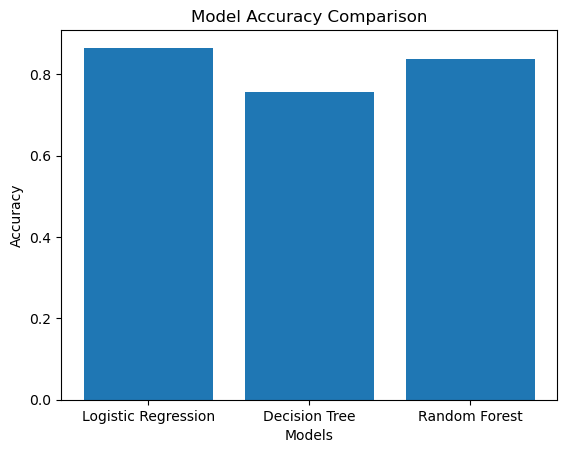

In [27]:
import matplotlib.pyplot as plt

plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [28]:
final_model = LogisticRegression(max_iter=1000)

final_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
sample1 = "python sql data analysis excel"

sample1 = sample1.lower()

X_test = vectorizer.transform([sample])

pred = model.predict(X_test)[0]

print("Prediction:", pred)

Prediction: Data Analytics Intern
